# Final Evaluation on the Unseen 2025 Season

This notebook runs the one-time, leakage-safe evaluation of our deployed model on the 2025
season, which was never used for training or model selection.

The deployed model is pre-lineup: it predicts run or pass from information available before
the offense lines up (down, distance, field position, score, clock, timeouts, betting
market). Pre-snap formation cues are excluded because they are only observable after the
offense lines up. For context we also evaluate an after-lineup model that adds those cues, to
show how much accuracy they would buy if we waited.

How we kept it honest. `02_modeling.ipynb` trained only on 2022-2023 and selected models and
hyper-parameters against the 2024 validation split. The final tuned model was refit on all of
2022-2024 and saved to `models/lgbm_runpass.joblib`. Here we load that frozen model, run it
once on 2025, and report the numbers. We do not re-tune anything based on what we see. The
same `src/features.py` pipeline is applied, so there is no train/serve skew.

Every model is reported with accuracy, precision, recall, F1, and ROC-AUC.

## 1. Setup and load the frozen model

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from src import features as F

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, brier_score_loss)
from sklearn.calibration import calibration_curve
import lightgbm as lgb
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

art = joblib.load("../models/lgbm_runpass.joblib")
model = art["model"]                       # deployed, pre-lineup (situation only)
SIT = art["features"]
formation_model = art["formation_model"]   # secondary: also uses post-lineup formation
FORM = art["formation_features"]
print("Deployed model: pre-lineup, situation only. Trained on seasons:", art["train_seasons"])
print("Params:", art["params"])
print("pre-lineup features:", len(SIT), "| after-lineup features:", len(FORM))

Deployed model: pre-lineup, situation only. Trained on seasons: [2022, 2023, 2024]
Params: {'learning_rate': 0.03, 'min_child_samples': 50, 'n_estimators': 400, 'num_leaves': 31}
pre-lineup features: 29 | after-lineup features: 31


## 2. Load the untouched 2025 test set

In [2]:
raw_test = F.load_seasons(["../data/test/play_by_play_2025.parquet"])
work = F.engineer(F.clean(raw_test))     # raw columns plus engineered ones plus target
X_test = work[SIT].copy()                # deployed (pre-lineup) model input
X_test_form = work[FORM].copy()          # after-lineup comparison input
y_test = work[F.TARGET].copy()

print(f"2025 test plays (clean run/pass): {len(work):,}")
print(f"2025 pass rate, the majority-class baseline accuracy: {y_test.mean():.4f}")

2025 test plays (clean run/pass): 34,503
2025 pass rate, the majority-class baseline accuracy: 0.5692


## 3. Evaluate on 2025

We compare the majority-class baseline, the deployed pre-lineup model, and the after-lineup
model that additionally sees the formation. The deployed model is the one we submit.

In [3]:
def metrics(name, y_true, y_pred, y_score):
    return {"Model": name,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_score)}

maj = np.ones_like(y_test)
maj_score = np.full(len(y_test), y_test.mean())
fp = model.predict(X_test); fs = model.predict_proba(X_test)[:, 1]                       # deployed
gp = formation_model.predict(X_test_form); gscore = formation_model.predict_proba(X_test_form)[:, 1]

rows = [
    metrics("Majority (always pass)", y_test, maj, maj_score),
    metrics("Deployed: pre-lineup (situation)", y_test, fp, fs),
    metrics("After lineup (+ formation)", y_test, gp, gscore),
]
final_tbl = pd.DataFrame(rows).set_index("Model").round(4)
final_tbl

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Majority (always pass),0.5692,0.5692,1.0000,0.7255,0.5000
Deployed: pre-lineup (situation),0.7002,0.7447,0.7201,0.7322,0.7704
After lineup (+ formation),0.7253,0.7559,0.7643,0.7601,0.7963


### Headline result

In [4]:
base = y_test.mean()
acc_dep = accuracy_score(y_test, fp)
acc_form = accuracy_score(y_test, gp)
print(f"Majority baseline (2025):                 {base:6.2%}")
print(f"Deployed pre-lineup model (2025):         {acc_dep:6.2%}")
print(f"After-lineup model, + formation (2025):   {acc_form:6.2%}")
print(f"Lift over baseline:                       +{acc_dep-base:5.2%}")
print(f"Extra from seeing the formation:          +{acc_form-acc_dep:5.2%}")
print()
print("The deployed model uses only pre-lineup information. Its 2025 test accuracy is close to")
print("the 2024 validation accuracy, so it generalizes to a future season. Seeing the formation")
print("would add a couple of points, but that information is not available before the lineup.")

Majority baseline (2025):                 56.92%
Deployed pre-lineup model (2025):         70.02%
After-lineup model, + formation (2025):   72.53%
Lift over baseline:                       +13.09%
Extra from seeing the formation:          +2.52%

The deployed model uses only pre-lineup information. Its 2025 test accuracy is close to
the 2024 validation accuracy, so it generalizes to a future season. Seeing the formation
would add a couple of points, but that information is not available before the lineup.


## 4. Confusion matrix and classification report (deployed model)

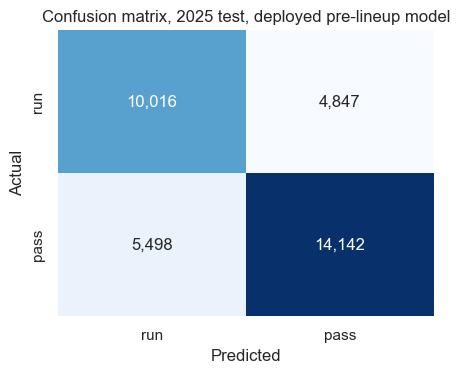

              precision    recall  f1-score   support

         run     0.6456    0.6739    0.6594     14863
        pass     0.7447    0.7201    0.7322     19640

    accuracy                         0.7002     34503
   macro avg     0.6952    0.6970    0.6958     34503
weighted avg     0.7020    0.7002    0.7009     34503



In [5]:
cm = confusion_matrix(y_test, fp)
fig, ax = plt.subplots(figsize=(4.6, 3.9))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["run","pass"], yticklabels=["run","pass"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix, 2025 test, deployed pre-lineup model")
plt.tight_layout(); plt.show()
print(classification_report(y_test, fp, target_names=["run","pass"], digits=4))

## 5. ROC curve

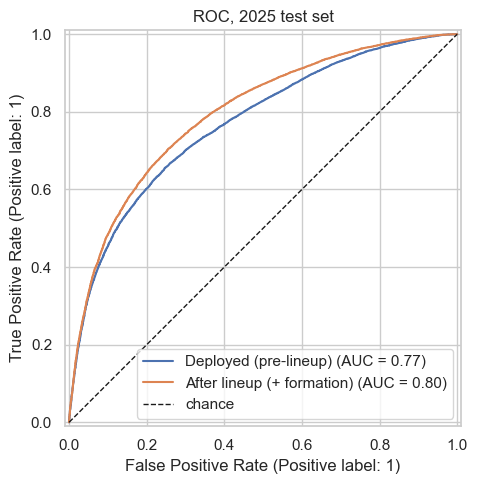

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, fs, name="Deployed (pre-lineup)", ax=ax, color="#4c72b0")
RocCurveDisplay.from_predictions(y_test, gscore, name="After lineup (+ formation)", ax=ax, color="#dd8452")
ax.plot([0,1],[0,1], "k--", lw=1, label="chance")
ax.set_title("ROC, 2025 test set"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. Feature importance (deployed model)

Which pre-lineup variables drove the model's decisions on unseen data?

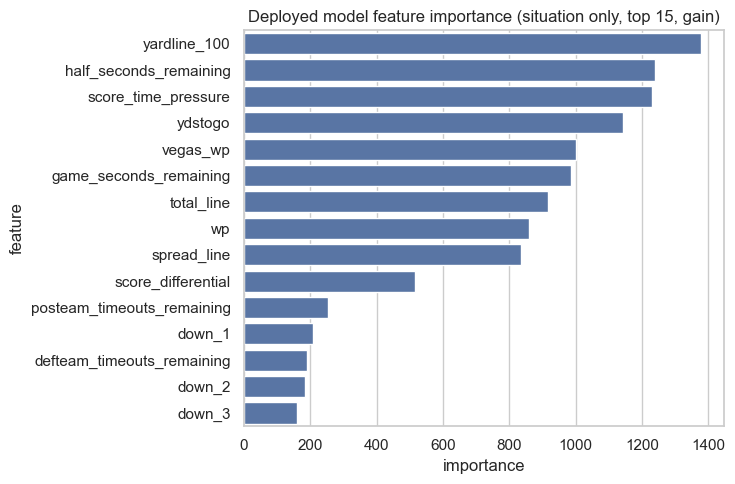

,feature,importance
0,yardline_100,1378
1,half_seconds_remaining,1239
2,score_time_pressure,1231
3,ydstogo,1144
4,vegas_wp,1001
5,game_seconds_remaining,987
6,total_line,917
7,wp,860
8,spread_line,834
9,score_differential,517


In [7]:
imp = (pd.DataFrame({"feature": SIT, "importance": model.feature_importances_})
       .sort_values("importance", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.barplot(data=imp, y="feature", x="importance", color="#4c72b0", ax=ax)
ax.set_title("Deployed model feature importance (situation only, top 15, gain)")
plt.tight_layout(); plt.show()
imp.reset_index(drop=True)

## 7. Probability calibration

A reliability curve checks whether predicted probabilities are trustworthy: when the model
says 70% pass, do about 70% of those plays end up passes? Good calibration is what makes the
demo's percentages meaningful.

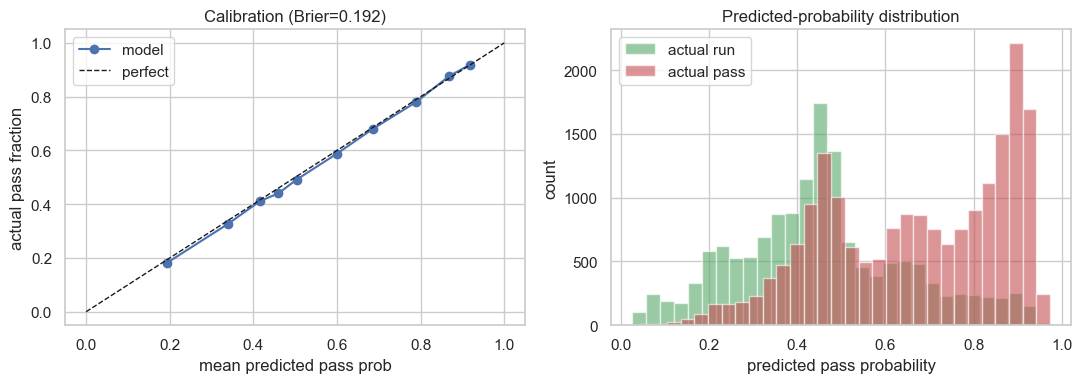

In [8]:
frac_pos, mean_pred = calibration_curve(y_test, fs, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, fs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mean_pred, frac_pos, "o-", color="#4c72b0", label="model")
axes[0].plot([0,1],[0,1], "k--", lw=1, label="perfect")
axes[0].set_xlabel("mean predicted pass prob"); axes[0].set_ylabel("actual pass fraction")
axes[0].set_title(f"Calibration (Brier={brier:.3f})"); axes[0].legend()
axes[1].hist(fs[y_test==0], bins=30, alpha=0.6, label="actual run", color="#55a868")
axes[1].hist(fs[y_test==1], bins=30, alpha=0.6, label="actual pass", color="#c44e52")
axes[1].set_xlabel("predicted pass probability"); axes[1].set_ylabel("count")
axes[1].set_title("Predicted-probability distribution"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Case studies

The rubric asks for cases where the model does very well or very poorly. We attach the
deployed model's predictions back to the raw situation columns and inspect the extremes.

In [9]:
look = work.copy()
look["pass_prob"] = fs
look["actual"] = np.where(y_test.values==1, "pass", "run")
look["pred"] = np.where(fp==1, "pass", "run")
cols = ["down","ydstogo","yardline_100","score_differential","qtr",
        "half_seconds_remaining","actual","pred","pass_prob"]

print("Most confident correct pass calls:")
print(look[(look.actual=="pass") & (look.pred=="pass")]
      .sort_values("pass_prob", ascending=False)[cols].head(5).to_string(index=False))

print("\nMost confident correct run calls:")
print(look[(look.actual=="run") & (look.pred=="run")]
      .sort_values("pass_prob")[cols].head(5).to_string(index=False))

print("\nMost confident mistakes (sure it was pass, was actually run):")
print(look[(look.actual=="run") & (look.pred=="pass")]
      .sort_values("pass_prob", ascending=False)[cols].head(5).to_string(index=False))

Most confident correct pass calls:
 down  ydstogo  yardline_100  score_differential  qtr  half_seconds_remaining actual pred  pass_prob
  2.0     10.0          29.0                -4.0  4.0                     4.0   pass pass   0.973167
  2.0     10.0          46.0                -3.0  4.0                     5.0   pass pass   0.972963
  2.0     10.0          58.0                -5.0  4.0                    30.0   pass pass   0.972132
  2.0     10.0          49.0                -4.0  4.0                     7.0   pass pass   0.971315
  1.0     10.0          53.0                -4.0  4.0                    15.0   pass pass   0.969483

Most confident correct run calls:
 down  ydstogo  yardline_100  score_differential  qtr  half_seconds_remaining actual pred  pass_prob
  1.0     10.0          62.0                18.0  4.0                   100.0    run  run   0.025819
  1.0     10.0          11.0                 6.0  4.0                    96.0    run  run   0.026192
  1.0     10.0       

### Accuracy by down and distance

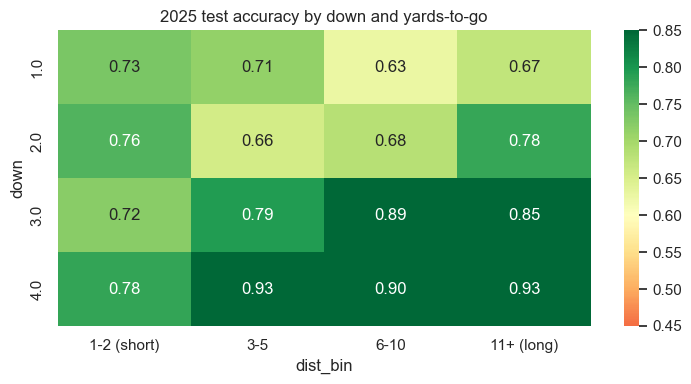

In [10]:
look["correct"] = (look["actual"] == look["pred"]).astype(int)
look["dist_bin"] = pd.cut(look["ydstogo"], [0,2,5,10,100],
                          labels=["1-2 (short)","3-5","6-10","11+ (long)"])
piv = look.pivot_table(index="down", columns="dist_bin", values="correct", aggfunc="mean")
fig, ax = plt.subplots(figsize=(7.5, 4))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", center=0.6, vmin=0.45, vmax=0.85, ax=ax)
ax.set_title("2025 test accuracy by down and yards-to-go"); ax.set_ylabel("down")
plt.tight_layout(); plt.show()

## 9. Does pre-lineup team identity help on the test set?

Team identity is available before the lineup, so it is a fair feature. In `02_modeling.ipynb`
it gave a small validation lift. Because team play-calling tendency is only weakly stable year
over year, we check whether that lift survives on 2025. Rates are fit on 2022-2024 and applied
once to 2025.

In [11]:
cols_t = list(F.RAW_COLUMNS)
def _load(paths):
    d = pd.concat([pd.read_parquet(p, columns=cols_t) for p in paths], ignore_index=True)
    return d[d["play_type"].isin(["run", "pass"])].copy()

tr_full = F.engineer(F.clean(_load([f"../data/train/play_by_play_{y}.parquet" for y in (2022,2023,2024)])))
te_full = F.engineer(F.clean(_load(["../data/test/play_by_play_2025.parquet"])))
rates = F.fit_team_rates(tr_full)
tr_full = F.add_team_features(tr_full, rates)
te_full = F.add_team_features(te_full, rates)

team_feats = SIT + F.TEAM_FEATURES
mt = lgb.LGBMClassifier(subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                        n_jobs=-1, verbose=-1, **art["params"]).fit(tr_full[team_feats], tr_full[F.TARGET])
tp = mt.predict(te_full[team_feats]); ts = mt.predict_proba(te_full[team_feats])[:, 1]

cmp = pd.DataFrame([
    metrics("Deployed (situation)", y_test, fp, fs),
    metrics("Situation + team identity", te_full[F.TARGET], tp, ts),
]).set_index("Model").round(4)
print(cmp.to_string())
print(f"\nAccuracy lift from team identity on 2025 test: "
      f"{cmp['Accuracy'].iloc[1] - cmp['Accuracy'].iloc[0]:+.4f}  "
      f"(small, consistent with the weak year-over-year stability seen in 02_modeling)")

                           Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                  
Deployed (situation)         0.7002     0.7447  0.7201  0.7322   0.7704
Situation + team identity    0.6991     0.7426  0.7214  0.7319   0.7687

Accuracy lift from team identity on 2025 test: -0.0011  (small, consistent with the weak year-over-year stability seen in 02_modeling)


## 10. Conclusions

On a completely unseen 2025 season, the deployed pre-lineup model clears the majority baseline
by a wide margin, and its accuracy matches the 2024 validation number, which is evidence that
it generalizes to a future season rather than overfitting the validation split.

Seeing the pre-snap formation would add a couple of accuracy points, but that information is
only available after the offense lines up, so the deployed pre-lineup model does not use it.
Team identity, although available before the lineup, adds very little on the test set, in line
with its weak year-over-year stability.

The model is best on obvious passing situations (3rd-and-long, two-minute, trailing late) and
weakest where play-calling is close to a coin flip (early down, medium distance), exactly the
situations where coaches stay unpredictable on purpose. Predicted probabilities are reasonably
well calibrated, which is what makes the interactive demo's percentages meaningful. Together
with the baselines, ablation, and parameter-sensitivity analyses in `02_modeling.ipynb`, these
results cover the rubric's Results section.